# Configuration

Here we illustrate how to create experimental configurations, using the ``atomsmltr.simulation.configurator`` subpackage

## Introduction to configurations

Configuration objects are at the heart of this package. They are the cement that allows to combine all the environment objects (lasers, magnetic fields, zones) and feed them into a simulation.

Here is how to create a configuration.

In [1]:
from atomsmltr.simulation import Configuration
from atomsmltr.atoms import Ytterbium

# init a configuration for ytterbium atoms
config = Configuration(atom=Ytterbium())

objects can be added to the configuration using the ``add_objects()`` method or the ``+=`` operator. The Configuration object will automatically sort them according to their type. 

**ATTENTION** objects are stored in internal dictionnaries, using their ``tag`` property as a key. Therefore, it is important to **define tags for the objects** and to make sure that objects do not have the same tags (otherwise, an error will be raised)

In [2]:
from atomsmltr.environment import Limits, MagneticOffset, MagneticGradient, GaussianLaserBeam

# let's define two lasers
laser1 = GaussianLaserBeam(tag="laser1")
laser2 = GaussianLaserBeam(tag="laser2")

# two magnetic fields
mag_offset = MagneticOffset((0,1,0), tag="offset")
mag_gradient = MagneticGradient((0,0,0), 0.5, (0,1,0), (0,0,1), tag="gradient")
# one limit
xlim = Limits(0, 10, axis=0, target="position")

# and add them
config.add_objects([laser1, mag_offset])   # we can provide a list
config.add_objects(xlim)  # a single object
config += mag_gradient, laser2  # or use the operator :)

now we can print the information

In [3]:
config.print_info()

# ------------ CONFIG INFO > START ------------ #
────────────────────────
| General informations |
────────────────────────
. atom :
  └── name : Ytterbium

. lasers :
  ├── laser1
  └── laser2

. magnetic fields :
  ├── offset
  └── gradient

. forces :
  └── empty

. zones :
  └── vazewa


────────────────────
| atom | ytterbium |
────────────────────
. Parameters :
  ├── mass (kg) : 2.89e-25
  └── mass (au) : 173.94

. Transition list :
  ├── main
  └── intercombination

. 'main' transition :
  ├── λ : 398.91 nm
  ├── Γ : 2π × 2.89e+07 Hz
  ├── Isat : 59.51 mw/cm²
  └── lande factor g : 1.035

. 'intercombination' transition :
  ├── λ : 555.80 nm
  ├── Γ : 2π × 1.82e+05 Hz
  ├── Isat : 0.14 mw/cm²
  └── lande factor g : 1.493


────────────────────────
| laser | tag='laser1' |
────────────────────────
. Parameters :
  ├── type : Gaussian beam
  ├── tag : laser1
  ├── waist (m) : 0.001
  ├── power (W) : 0.001
  ├── waist position (m) : [0 0 0]
  ├── direction type : vector
  ├── dir

## Manage objects in a collection

Currently, our convention is that **copies** of objects are stored in the configuration object. This way, if an object is modified after it has been added in the configuration, this modification won't affect the configuration.

It might be that we change this behaviour at some point... this is to be discussed.

The configuration object comes with a lot of useful methods to manage the objects. Here are some examples ; for more information, please have a look at the **API documentation**

In [4]:
from atomsmltr.simulation import Configuration
from atomsmltr.atoms import Ytterbium
from atomsmltr.environment import Limits, MagneticOffset, MagneticGradient, GaussianLaserBeam

# - INIT
# let's define some objects
laser1 = GaussianLaserBeam(tag="laser1")
laser2 = GaussianLaserBeam(tag="laser2")
mag_offset = MagneticOffset((0,1,0), tag="offset")

# init a configuration for ytterbium atoms
config = Configuration(atom=Ytterbium())

# add objects
config += laser1, laser2, mag_offset

In [5]:
# - REMOVE AN OBJECT
print(config.list_lasers())
config.rm_laser("laser1")
print(config.list_lasers())

['laser1', 'laser2']
['laser2']


In [6]:
# - REMOVE ALL OBJECTS
# all lasers
config.rm_all_lasers()
print(config.list_lasers())
print(config.list_magnetic_fields())

# everything
config.rm_all_objects()
print(config.list_magnetic_fields())

[]
['offset']
[]


In [7]:
# - UPDATE AN OBJECT
# reset
config.rm_all_objects()

# add a laser > a copy is stored
laser1.wavelength = 399e-9
config += laser1

# check wavelength of laser stored
print(config.get_laser_copy("laser1").wavelength)

# update the laser > the stored version is not affected
laser1.wavelength = 556e-9
print(config.get_laser_copy("laser1").wavelength)

# to change the config, laser has to be updated
config.update_objects(laser1)
print(config.get_laser_copy("laser1").wavelength)


3.99e-07
3.99e-07
5.56e-07


## Setting up atom-light couplings

### Defining a single-frequency coupling

In order to give the user a full control on atom-light interactions, we decided to make the configuration object ignorant of any atom-light interaction coupling. Hence, it is not sufficient to add an atom and a laser with compatible wavelengths for the two to interact.

Atom-light coupling are given by hand using the ``add_atomlight_coupling()`` method, associating a laser and a transition using their *tags*.

In [8]:
from atomsmltr.simulation import Configuration
from atomsmltr.atoms import Ytterbium
from atomsmltr.environment import PlaneWaveLaserBeam

# init a configuration for ytterbium atoms
config = Configuration(atom=Ytterbium())

# get ytterbium main transition information
main = config.atom.trans["main"]

# create a plane wave laser
laser = PlaneWaveLaserBeam()
laser.wavelength = main.wavelength
laser.set_power_from_I(main.Isat)  # set power to have I=Isat
laser.tag = "399"

# add laser to config
config += laser

# create a coupling
config.add_atomlight_coupling(
    laser="399",
    transition="main",
    detuning=-2 * main.Gamma,
)

# show info
config.print_atomlight_info()

────────────────────────
| Atom-light couplings |
────────────────────────
. transition > 'main' :
  └── laser '399' : detuning=-3.63e+08 (-2.00Γ)

. transition > 'intercombination' :
  └── empty




### Multi-frequency atom-light coupling

In some cases, the spectrum of a laser might present multiple frequencies, such that the atom-light coupling should be defined with multiple detunings. A first option to simulate this situation in ``atomsmltr`` would be to define *one laser beam for each frequency component*, and then to set up the corresponding couplings with different detunings via the ``add_atomlight_coupling()`` method. However, with this method the effect of atom-light interaction will be calculated independently for each laser, and will for instance require to compute the laser intensity and polarization for each component, which is not so efficient.

To circumvent that, it is possible to define the detuning as a list of detuning values ``[δ1, δ2, δ3]``, or a list of tuples defining a detuning value and a relative weight ``[(δ1, weight1), (δ2, weight2)]``. Our convention for the weights is the following:

+ if no weight is given, we assume a weight of 1
+ the atom-light interaction is then computed, for each detuning, with an intensity ``I0 * weight``

Where ``I0`` is the total intensity of the laser beam. Note that then weights are given, we do not check the normalization of the intensity. It is up to the user to provide the good values for the laser beam intensity and the weights to account for a physical configuration. Specifically, if the sum of the weights exceeds one, the laser intensity seen by the atoms will be larger than the laser intensity specified when defining the ``LaserBeam`` environment object.

For instance, if the configuration contains a laser beam with a total power of 100mW, a list of detuning ``[(δ1, 0.5), (δ2, 0.5)]`` would correspond to two frequency components with each 50mW of power, whereas a list
``[δ1, δ2]`` would actually correspond to two laser beams of 100mW with detunings δ1 and δ2.

We illustrate this bellow by comparing the force computed using a single laser beam with multiple atom-light coupling defined, and a corresponding collection of individual laser beams.

In [35]:
from atomsmltr.simulation import Configuration
from atomsmltr.atoms import Ytterbium
from atomsmltr.environment import PlaneWaveLaserBeam, MagneticGradient, CircularRight

# prepare two configs
config_multibeams = Configuration(atom=Ytterbium())
config_singlebeam = Configuration(atom=Ytterbium())

# get ytterbium main transition information
main = Ytterbium().trans["main"]

# create a plane wave laser
laser = PlaneWaveLaserBeam()
laser.wavelength = main.wavelength
laser.set_power_from_I(main.Isat)  # set power to have I=Isat
laser.tag = "399"
laser.direction = (-1, 0, 0)  # propagates along -x
laser.polarization = CircularRight()

# add a gradient
mag_gradient = MagneticGradient(
    origin=(0, 0, 0),
    slope=0.1,
    gradient_direction=(1, 0, 0),
    field_direction=(1, 0, 0),
)

# add the gradient for the two configs
config_singlebeam += mag_gradient
config_multibeams += mag_gradient

# define couplings : three detunings, with decreasing relative weight
detunings = [(-main.Gamma, 0.5), (-5 * main.Gamma, 0.3), (-10 * main.Gamma, 0.2)]

# first config with one laser beam, using the multi-frequency atom-light coupling feature
config_singlebeam += laser  # single laser
config_singlebeam.add_atomlight_coupling(
    laser="399", transition="main", detuning=detunings
)

# second config with three laser beams and single frequency coupling
total_power = laser.power
for i, (delta, weight) in enumerate(detunings):
    # add a dedicated laser with a new tag and corrected intensity
    laser.tag = f"399-{i+1}"
    laser.power = total_power * weight
    config_multibeams += laser
    # setup coupling
    config_multibeams.add_atomlight_coupling(
        laser=laser, transition="main", detuning=delta
    )


# show info
config_singlebeam.print_atomlight_info()
config_multibeams.print_atomlight_info()

────────────────────────
| Atom-light couplings |
────────────────────────
. transition > 'main' :
  └── laser '399' : -1.82e+08 (-1.00Γ) * w=0.5, -9.08e+08 (-5.00Γ) * w=0.3, -1.82e+09 (-10.00Γ) * w=0.2

. transition > 'intercombination' :
  └── empty


────────────────────────
| Atom-light couplings |
────────────────────────
. transition > 'main' :
  ├── laser '399-1' : -1.82e+08 (-1.00Γ)
  ├── laser '399-2' : -9.08e+08 (-5.00Γ)
  └── laser '399-3' : -1.82e+09 (-10.00Γ)

. transition > 'intercombination' :
  └── empty




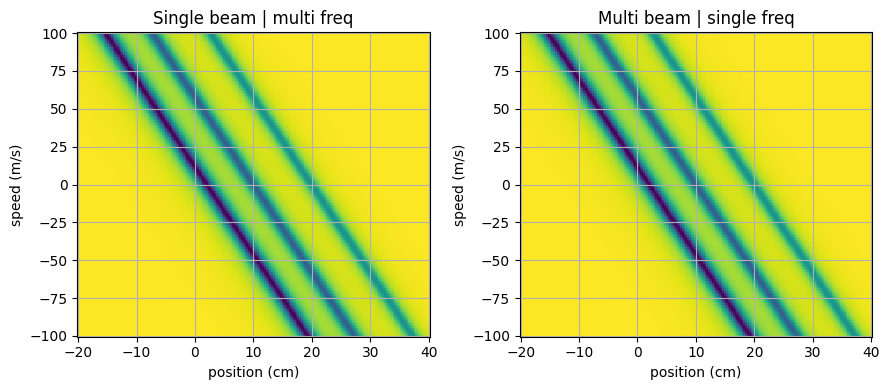

In [39]:
# -- Plotting the force, using simulator objects
# imports
import numpy as np
import matplotlib.pyplot as plt
from atomsmltr.simulation import RK4

# define simulations
sim_singlebeam = RK4(config_singlebeam)
sim_multibeams = RK4(config_multibeams)

# prepare grid

grid = np.mgrid[-0.2:0.4:200j, 0:0:1j, 0:0:1j, -100:100:201j, 0:0:1j, 0:0:1j]
grid = np.squeeze(grid)
pos = grid.T
X, _, _, VX, _, _ = grid

# compute force
force_singlebeam = sim_singlebeam.get_force(pos)
FX_singlebeam, _, _ = force_singlebeam.T
force_multibeams = sim_multibeams.get_force(pos)
FX_multibeams, _, _ = force_multibeams.T

# normalize to same value
F_max = np.max(np.abs(FX_singlebeam))

# prepare figure
fix, ax = plt.subplots(1, 2, figsize=(9, 4), tight_layout=True)

# plot single beam force
c = ax[0].pcolormesh(X * 100, VX, FX_singlebeam / F_max)
ax[0].set_title("Single beam | multi freq")

# plot multi beam
ax[1].pcolormesh(X * 100, VX, FX_singlebeam / F_max)
ax[1].set_title("Multi beam | single freq")

# setup and show
for cax in ax:
    cax.set_xlabel("position (cm)")
    cax.set_ylabel("speed (m/s)")
    cax.grid()

plt.show()